#### **PT-BR**
# **Pipeline Analítico de Processamento de Linguagem Natural (PLN) - PubMed**
Por: Davi Santos

Este notebook implementa uma arquitetura completa e escalável de PLN voltada para a extração de insights de textos científicos da base de dados médica PubMed. A solução encapsula todo o ciclo de vida dos dados, desde a ingestão resiliente até a inferência com inteligência artificial, utilizando boas práticas de engenharia de software para garantir a estabilidade do fluxo.

Módulos do Pipeline:

1. **Data Ingestion**: Coleta automatizada e resiliente de abstracts via API do NCBI.

2. **Pré-processamento Avançado**: Limpeza, tokenização e lematização otimizada em cache para o domínio médico.

3. **Vetorização Semântica**: Geração de embeddings textuais (Sentence Transformers) e representações vetoriais de contingência (TF-IDF).

4. **Modelagem de Linguagem e Inferência**:

    ● **Classificação**: Treinamento de modelos tradicionais (Random Forest/GaussianNB) e inferência Zero-Shot com Transformers (BART).

    ● **Tópicos (Topic Modeling)**: Agrupamento não supervisionado de temas utilizando LDA (Latent Dirichlet Allocation).

    ● **Sumarização Automática**: Geração de resumos extrativos (LSA) e abstrativos (BART).

______________________________________________________________________________________
#### **EN**
# **Natural Language Processing (NLP) Analytical Pipeline - PubMed**
By: Davi Santos

This notebook implements a complete and scalable NLP architecture designed to extract insights from scientific texts within the PubMed medical database. The solution encapsulates the entire data lifecycle—from resilient data ingestion to AI-driven inference—employing software engineering best practices to ensure pipeline stability.

**Pipeline Modules:**

1. Data Ingestion: Automated and resilient collection of abstracts via the NCBI API.

2. Advanced Preprocessing: Cleaning, tokenization, and cache-optimized lemmatization tailored for the medical domain.

3. Semantic Vectorization: Generation of textual embeddings (Sentence Transformers) alongside fallback vector representations (TF-IDF).

4. Language Modeling and Inference:

   ● Classification: Training of traditional models (Random Forest/GaussianNB) and Zero-Shot inference using Transformers (BART).

   ● Topic Modeling: Unsupervised thematic clustering using LDA (Latent Dirichlet Allocation).

   ● Automated Summarization: Generation of extractive (LSA) and abstractive (BART) summaries.

In [39]:
# Importações
import os
import pandas as pd
import numpy as np
import re
import logging
import warnings
import sys
import importlib.util
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from typing import Dict, List, Tuple, Optional
from collections import Counter
from Bio import Entrez
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from functools import lru_cache

warnings.filterwarnings('ignore')

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# Configuração centralizada
class NLPConfig:
    """Configuração centralizada do pipeline NLP"""
    
    # Embeddings
    EMBEDDINGS_MODEL = 'all-MiniLM-L6-v2'
    EMBEDDINGS_BATCH_SIZE = 32
    
    # Fallback TF-IDF
    TFIDF = {
        'max_features': 200,
        'min_df': 2,
        'max_df': 0.8,
        'ngram_range': (1, 2),
        'sublinear_tf': True,
        'norm': 'l2',
        'strip_accents': 'unicode'
    }
    
    # LDA
    LDA = {
        'num_topics': 4,
        'passes': 10,
        'per_word_topics': True,
        'minimum_probability': 0.0,
        'random_state': 42
    }
    
    # Modelos
    RANDOM_FOREST = {
        'n_estimators': 100,
        'random_state': 42,
        'min_samples_split': 5,
        'max_depth': None
    }

# Gerenciar os pacotes
class PackageManager:
    """Gerenciamento unificado de dependências opcionais"""
    
    PACKAGES = {
        'transformers': ['transformers', 'torch'],
        'sentence_transformers': ['sentence_transformers'],
        'gensim': ['gensim', 'pyLDAvis'],
        'sumy': ['sumy']
    }

    INSTALL_PACKAGES = {
        'transformers': ['transformers', 'torch'],
        'sentence_transformers': ['sentence-transformers'],
        'gensim': ['gensim', 'pyLDAvis'],
        'sumy': ['sumy']
    }
    
    def __init__(self):
        self.status = {}
        self.check_all()
    
    def check_all(self):
        for package_group, packages in self.PACKAGES.items():
            self.status[package_group] = self._check_package_group(packages)
            
            if not self.status[package_group]:
                install_list = self.INSTALL_PACKAGES.get(package_group, packages)
                logger.warning(
                    f"{package_group} indisponível: {packages}. "
                    f"Instale com: pip install {' '.join(install_list)}"
                )
    
    def _check_package_group(self, packages):
        try:
            for pkg in packages:
                __import__(pkg)
            return True
        except (ImportError, OSError):
            return False
    
    def is_available(self, package_group):
        return self.status.get(package_group, False)

# Inicialização do gerenciador de pacotes
pkg_manager = PackageManager()
transformers_available = pkg_manager.is_available('transformers')
embeddings_available = pkg_manager.is_available('sentence_transformers')
gensim_available = pkg_manager.is_available('gensim')
sumy_available = pkg_manager.is_available('sumy')

# Modelo de embeddings
sentence_model = None

In [40]:
# Configuração do Entrez
load_dotenv()  # Carrega variáveis do arquivo .env
Entrez.api_key = os.environ.get('ENTREZ_API_KEY')

print("Configuração Concluída!")

Configuração Concluída!


In [41]:
print("Checagem do Ambiente")
print("-"*60 + "\n")

required_packages = [
    'pandas', 'numpy', 'nltk',
    'transformers', 'gensim', 'matplotlib', 'seaborn',
    'sumy', 'pyLDAvis'
]
optional_packages = ['torch']
missing_packages = []
optional_issues = []
for package in required_packages + optional_packages:
    try:
        if package == 'torch':
            spec = importlib.util.find_spec('torch')
            if spec is None:
                optional_issues.append(package)
            else:
                try:
                    import torch  # type: ignore
                except (ImportError, OSError) as e:
                    print(f"Aviso: '{package}' foi encontrado, mas não pôde ser carregado: {e}")
                    optional_issues.append(package)
        else:
            __import__(package)
    except ImportError:
        if package in optional_packages:
            optional_issues.append(package)
        else:
            missing_packages.append(package)
    except OSError as e:
        print(f"Aviso: falha ao carregar '{package}': {e}")
        if package in optional_packages:
            optional_issues.append(package)
        else:
            missing_packages.append(package)

print(f"Versão do Python: {sys.version.split()[0]}")
print(f"Entrez API Key: {'*' * 8}...{Entrez.api_key[-4:] if Entrez.api_key else 'Não configurada'}")  # Mostra apenas últimos 4 caracteres
print(f"Disponibilidade do Transformers: {transformers_available}")
print(f"Disponibilidade do Gensim: {gensim_available}")
print(f"Disponibildade do Sumy: {sumy_available}")
print()
if missing_packages:
    print("Pacotes faltantes detectados:")
    for pkg in missing_packages:
        print(f"  - {pkg}")
    print()
    print("Instale com:")
    print(f"  python -m pip install {' '.join(missing_packages)}")
    print()
else:
    print("Todos os pacotes necessários estão instalados.")

if optional_issues:
    print("\nPacotes opcionais com falha de importação:")
    for pkg in optional_issues:
        print(f"  - {pkg}")
    print("\nNota: 'torch' é opcional para este notebook se você não usar modelos pré-treinados do transformers.")
    print("Se precisar de torch no CPU-only, instale com:")
    print("  python -m pip install torch --index-url https://download.pytorch.org/whl/cpu")
print("-"*60 + "\n")


Checagem do Ambiente
------------------------------------------------------------

Versão do Python: 3.11.9
Entrez API Key: ********...c908
Disponibilidade do Transformers: True
Disponibilidade do Gensim: True
Disponibildade do Sumy: True

Todos os pacotes necessários estão instalados.
------------------------------------------------------------



In [42]:
# 1. COLETA DE DADOS DO PubMed
# ------------------------------------------------------------------------------

def buscar_resumos(term: str, n: int = 200, retries: int = 3) -> list[dict]:
    """
    Busca resumos científicos no PubMed com tratamento de erros.
    
    Args:
        term: Termo de busca (ex: "Cardiology")
        n: Número máximo de resultados (padrão: 25)
        retries: Número de tentativas em caso de erro
    
    Returns:
        Lista de dicionários contendo PMID e abstract
    """
    for attempt in range(retries):
        try:
            logger.info(f"Buscando {n} artigos para '{term}' (tentativa {attempt + 1}/{retries})")
            
            # Buscar IDs
            handle = Entrez.esearch(db="pubmed", term=term, retmax=n)
            record = Entrez.read(handle)
            ids = record["IdList"]
            handle.close()
            
            if not ids:
                logger.warning(f"Nenhum resultado encontrado para '{term}'")
                return []
            
            logger.info(f"Encontrados {len(ids)} artigos. Baixando abstracts...")
            
            # Fetch dos abstracts em formato XML para melhor parsing
            handle = Entrez.efetch(db="pubmed", id=",".join(ids), rettype="xml", retmode="xml")
            records = Entrez.read(handle)
            handle.close()
            
            abstracts = []
            for paper in records["PubmedArticle"]:
                try:
                    pmid = paper["MedlineCitation"]["PMID"]
                    abstract_text = paper["MedlineCitation"]["Article"]["Abstract"]["AbstractText"]
                    
                    # Tratar caso onde abstract é uma lista ou string
                    if isinstance(abstract_text, list):
                        abstract = " ".join([str(t) for t in abstract_text])
                    else:
                        abstract = str(abstract_text)
                    
                    if abstract.strip():
                        abstracts.append({
                            "pmid": str(pmid),
                            "texto": abstract,
                            "tema": term
                        })
                except (KeyError, IndexError):
                    continue
            
            logger.info(f"✓ {len(abstracts)} abstracts coletados com sucesso")
            return abstracts
            
        except Exception as e:
            logger.warning(f"Erro na tentativa {attempt + 1}: {str(e)}")
            if attempt == retries - 1:
                logger.error(f"Falha ao buscar '{term}' após {retries} tentativas")
                return []


In [43]:
# Buscar resumos para múltiplas áreas
print("ETAPA 1: COLETA DE DADOS DO PUBMED")
print("-"*60 + "\n")

temas = ["Cardiology", "Oncology", "Neurology", "Dermatology"]
todos_os_dados = []

for tema in temas:
    abstracts = buscar_resumos(tema, n=20)
    todos_os_dados.extend(abstracts)

# Criação do DataFrame
df = pd.DataFrame(todos_os_dados)
logger.info(f"Total de documentos coletados: {len(df)}")

print(f"\nDataFrame criado com {len(df)} documentos")
print(f"Distribuição por tema:\n{df['tema'].value_counts()}\n")
print("Primeiras 3 linhas do dataset:")
df.head(3)

2026-04-15 17:31:30,237 - INFO - Buscando 20 artigos para 'Cardiology' (tentativa 1/3)


ETAPA 1: COLETA DE DADOS DO PUBMED
------------------------------------------------------------



2026-04-15 17:31:31,822 - INFO - Encontrados 20 artigos. Baixando abstracts...
2026-04-15 17:31:33,736 - INFO - ✓ 13 abstracts coletados com sucesso
2026-04-15 17:31:33,736 - INFO - Buscando 20 artigos para 'Oncology' (tentativa 1/3)
2026-04-15 17:31:34,429 - INFO - Encontrados 20 artigos. Baixando abstracts...
2026-04-15 17:31:35,923 - INFO - ✓ 13 abstracts coletados com sucesso
2026-04-15 17:31:35,925 - INFO - Buscando 20 artigos para 'Neurology' (tentativa 1/3)
2026-04-15 17:31:36,434 - INFO - Encontrados 20 artigos. Baixando abstracts...
2026-04-15 17:31:37,690 - INFO - ✓ 14 abstracts coletados com sucesso
2026-04-15 17:31:37,691 - INFO - Buscando 20 artigos para 'Dermatology' (tentativa 1/3)
2026-04-15 17:31:38,329 - INFO - Encontrados 20 artigos. Baixando abstracts...
2026-04-15 17:31:39,445 - INFO - ✓ 13 abstracts coletados com sucesso
2026-04-15 17:31:39,449 - INFO - Total de documentos coletados: 53



DataFrame criado com 53 documentos
Distribuição por tema:
tema
Neurology      14
Cardiology     13
Oncology       13
Dermatology    13
Name: count, dtype: int64

Primeiras 3 linhas do dataset:


,pmid,texto,tema
0,41984505,"Myocarditis, primarily induced by viral infect...",Cardiology
1,41984487,Since the publication of the 2021 Asian Pacifi...,Cardiology
2,41984469,Adverse myocardial remodeling and fibrosis con...,Cardiology


In [44]:
# PIPELINE UNIFICADO DE NLP
# ------------------------------------------------------------------------------

# Preparar recurso de stopwords com fallback
try:
    from nltk.corpus import stopwords
    stop_words_en = set(stopwords.words('english'))
except (LookupError, ImportError):
    logger.warning("NLTK stopwords não disponível, usando lista embutida")
    stop_words_en = {
        'the', 'be', 'to', 'of', 'and', 'a', 'in', 'that', 'have', 'i',
        'it', 'for', 'not', 'on', 'with', 'he', 'as', 'you', 'do', 'at',
        'this', 'but', 'his', 'by', 'from', 'they', 'we', 'or', 'an', 'my',
        'one', 'all', 'would', 'there', 'their', 'is', 'was', 'are', 'been',
        'being', 'should', 'will', 'can', 'could', 'may', 'might', 'must',
        'shall', 'was', 'were', 'been', 'being', 'which', 'what', 'who',
        'where', 'when', 'why', 'how', 'if', 'because', 'while', 'after',
        'before', 'between', 'during', 'above', 'below', 'through', 'under',
        'over', 'again', 'further', 'then', 'once', 'here', 'there', 'both',
        'each', 'few', 'more', 'most', 'some', 'any', 'no', 'nor', 'such',
        'same', 'so', 'than', 'too', 'very', 'just', 'only', 'own'
    }

class PreprocessadorTexto:
    """Classe para pré-processamento de textos científicos"""
    
    def __init__(self):
        self.lemmatizer = WordNetLemmatizer()
        self.stop_words = stop_words_en.copy()
        # Adicionar stop words específicos do domínio médico
        self.stop_words.update(['background', 'objective', 'methods', 'results', 
                                 'conclusions', 'purpose', 'study', 'patients'])
    
    def limpar_texto(self, texto: str) -> str:
        """Remove caracteres especiais e normaliza o texto"""
        # Converter para minúsculas
        texto = texto.lower()
        # Remover URLs
        texto = re.sub(r'http\S+|www\S+', '', texto)
        # Remover citações e números entre parênteses
        texto = re.sub(r'\(\d+\)', '', texto)
        # Remover caracteres especiais mantendo espaço
        texto = re.sub(r'[^a-z0-9\s\-]', ' ', texto)
        # Remover espaços múltiplos
        texto = ' '.join(texto.split())
        return texto
    
    def tokenizar_e_lemmatizar(self, texto: str) -> List[str]:
        """Tokeniza e lematiza o texto"""
        # Usar split simples em vez de word_tokenize, requer punkt
        tokens = texto.split()
        tokens = [self.lemmatizer.lemmatize(token) for token in tokens 
                  if token not in self.stop_words and len(token) > 2]
        return tokens
    
    def processar(self, texto: str) -> str:
        """Realiza o pré-processamento completo"""
        texto_limpo = self.limpar_texto(texto)
        tokens = self.tokenizar_e_lemmatizar(texto_limpo)
        return " ".join(tokens)

class NLPPipeline:
    """Pipeline completo de NLP para análise de textos médicos"""
    
    def __init__(self, config=None):
        self.config = config or NLPConfig()
        self.df = None
        self.vectorizer = None
        self.embedding_model = None
        self.embedding_matrix = None
        self.lda_model = None
        self.rf_model = None
        self.preprocessador = PreprocessadorTexto()
        self.pkg_manager = PackageManager()
    
    def run_collection(self, terms: List[str], n_per_term: int = 20):
        """Etapa 1: Coleta de dados do PubMed"""
        logger.info("Iniciando coleta de dados...")
        all_abstracts = []
        for term in terms:
            abstracts = buscar_resumos(term, n=n_per_term)
            all_abstracts.extend(abstracts)
        
        self.df = pd.DataFrame(all_abstracts)
        logger.info(f"✓ {len(self.df)} documentos coletados")
        return self
    
    def run_preprocessing(self):
        """Etapa 2: Pré-processamento de textos"""
        logger.info("Iniciando pré-processamento...")
        
        @lru_cache(maxsize=1024)
        def processar_cache(texto: str) -> str:
            return self.preprocessador.processar(texto)
        
        self.df['texto_processado'] = self.df['texto'].apply(processar_cache)
        self.df['num_tokens'] = self.df['texto_processado'].apply(lambda x: len(x.split()))
        
        logger.info("Pré-processamento concluído")
        return self
    
    def run_vectorization(self):
        """Etapa 3: Vetorização por embeddings semânticos"""
        logger.info("Iniciando vetorização de embeddings...")
        global sentence_model
        
        if embeddings_available:
            try:
                from sentence_transformers import SentenceTransformer
                self.embedding_model = SentenceTransformer(self.config.EMBEDDINGS_MODEL)
                sentence_model = self.embedding_model
                self.embedding_matrix = self.embedding_model.encode(
                    self.df['texto_processado'].tolist(),
                    batch_size=self.config.EMBEDDINGS_BATCH_SIZE,
                    show_progress_bar=False,
                    convert_to_numpy=True,
                    normalize_embeddings=True
                )
                logger.info(f"✓ Embeddings calculados: {self.embedding_matrix.shape}")
            except Exception as e:
                logger.warning(f"Erro ao carregar SentenceTransformer: {e}. Usando TF-IDF fallback.")
                self.vectorizer = TfidfVectorizer(**self.config.TFIDF)
                self.embedding_matrix = self.vectorizer.fit_transform(self.df['texto_processado']).toarray()
                logger.info(f"✓ Matriz TF-IDF criada: {self.embedding_matrix.shape}")
        else:
            logger.warning("sentence-transformers não disponível, usando TF-IDF fallback")
            self.vectorizer = TfidfVectorizer(**self.config.TFIDF)
            self.embedding_matrix = self.vectorizer.fit_transform(self.df['texto_processado']).toarray()
            logger.info(f"✓ Matriz TF-IDF criada: {self.embedding_matrix.shape}")
        return self
    
    def run_classification(self):
        """Etapa 4: Classificação com Random Forest"""
        if not validar_dataset(self.df):
            logger.warning("Dataset não válido para classificação")
            return self
        
        logger.info("Iniciando classificação...")
        
        X_train, X_test, y_train, y_test = train_test_split(
            self.embedding_matrix, self.df['tema'], test_size=0.2, 
            random_state=42, stratify=self.df['tema']
        )
        
        self.rf_model = RandomForestClassifier(**self.config.RANDOM_FOREST)
        self.rf_model.fit(X_train, y_train)
        
        accuracy = self.rf_model.score(X_test, y_test)
        logger.info(f"✓ Modelo treinado com acurácia: {accuracy:.2%}")
        
        self.classification_results = {
            'accuracy': accuracy,
            'model': self.rf_model
        }
        return self
    
    def run_topic_modeling(self):
        """Etapa 5: Modelagem de tópicos LDA"""
        if not self.pkg_manager.is_available('gensim'):
            logger.warning("Gensim não disponível, pulando LDA")
            return self
        
        logger.info("Iniciando modelagem de tópicos...")
        
        from gensim import corpora
        from gensim.models import LdaModel
        
        textos_tokenizados = [texto.split() for texto in self.df['texto_processado']]
        dictionary = corpora.Dictionary(textos_tokenizados)
        corpus = [dictionary.doc2bow(texto) for texto in textos_tokenizados]
        
        self.lda_model = LdaModel(
            corpus=corpus,
            id2word=dictionary,
            **self.config.LDA
        )
        
        logger.info("Modelo LDA treinado")
        return self
    
    def get_summary(self):
        """Retorna resumo dos resultados"""
        embedding_dim = self.embedding_matrix.shape[1] if hasattr(self, 'embedding_matrix') else 0
        summary = {
            "Total de documentos": len(self.df) if self.df is not None else 0,
            "Especialidades": list(self.df['tema'].unique()) if self.df is not None else [],
            "Dimensão do embedding": embedding_dim,
            "Acurácia RF": f"{self.classification_results['accuracy']:.2%}" if hasattr(self, 'classification_results') else "N/A",
            "Tópicos LDA": self.config.LDA['num_topics'] if self.lda_model else "N/A"
        }
        return summary

# Exemplo de uso do pipeline unificado
print("PIPELINE UNIFICADO - DEMONSTRAÇÃO")
print("-"*60 + "\n")

# Função auxiliar para validação
def validar_dataset(df: pd.DataFrame, min_docs: int = 20) -> bool:
    """Valida se o dataset é adequado para processamento"""
    if df.empty:
        raise ValueError("Dataset vazio. Verifique a coleta de dados.")
    if len(df) < min_docs:
        logger.warning(f"Apenas {len(df)} documentos (recomendado: {min_docs}+)")
    if df['tema'].nunique() < 2:
        raise ValueError("Precisa de pelo menos 2 classes para classificação")
    return True

# Criar e executar pipeline
pipeline = (NLPPipeline()
    .run_collection(['Cardiology', 'Oncology', 'Neurology', 'Dermatology'], n_per_term=15)
    .run_preprocessing()
    .run_vectorization()
    .run_classification()
    .run_topic_modeling())

# Exibir resumo
resumo = pipeline.get_summary()
print("RESUMO DO PIPELINE:")
for key, value in resumo.items():
    print(f"  {key}: {value}")

print("\nPipeline unificado executado com sucesso!")

2026-04-15 17:31:45,577 - INFO - Iniciando coleta de dados...
2026-04-15 17:31:45,578 - INFO - Buscando 15 artigos para 'Cardiology' (tentativa 1/3)


PIPELINE UNIFICADO - DEMONSTRAÇÃO
------------------------------------------------------------



2026-04-15 17:31:46,104 - INFO - Encontrados 15 artigos. Baixando abstracts...
2026-04-15 17:31:47,216 - INFO - ✓ 9 abstracts coletados com sucesso
2026-04-15 17:31:47,217 - INFO - Buscando 15 artigos para 'Oncology' (tentativa 1/3)
2026-04-15 17:31:47,911 - INFO - Encontrados 15 artigos. Baixando abstracts...
2026-04-15 17:31:49,109 - INFO - ✓ 12 abstracts coletados com sucesso
2026-04-15 17:31:49,110 - INFO - Buscando 15 artigos para 'Neurology' (tentativa 1/3)
2026-04-15 17:31:49,627 - INFO - Encontrados 15 artigos. Baixando abstracts...
2026-04-15 17:31:50,746 - INFO - ✓ 12 abstracts coletados com sucesso
2026-04-15 17:31:50,748 - INFO - Buscando 15 artigos para 'Dermatology' (tentativa 1/3)
2026-04-15 17:31:51,260 - INFO - Encontrados 15 artigos. Baixando abstracts...
2026-04-15 17:31:52,210 - INFO - ✓ 9 abstracts coletados com sucesso
2026-04-15 17:31:52,213 - INFO - ✓ 42 documentos coletados
2026-04-15 17:31:52,214 - INFO - Iniciando pré-processamento...
2026-04-15 17:31:52,257 

RESUMO DO PIPELINE:
  Total de documentos: 42
  Especialidades: ['Cardiology', 'Oncology', 'Neurology', 'Dermatology']
  Dimensão do embedding: 384
  Acurácia RF: 66.67%
  Tópicos LDA: 4

Pipeline unificado executado com sucesso!


In [45]:
# 2. PRÉ-PROCESSAMENTO DE TEXTO - APLICAÇÃO
# -------------------------------------------------------------------------------
print("ETAPA 2: PRÉ-PROCESSAMENTO DE TEXTO")
print("-"*60 + "\n")

# Download de recursos NLTK com tratamento de erro
resources = ['stopwords', 'wordnet', 'averaged_perceptron_tagger', 'punkt_tab', 'punkt']
for resource in resources:
    try:
        nltk.download(resource, quiet=True)
    except Exception as e:
        logger.warning(f"Não foi possível baixar {resource}: {e}")

preprocessador = PreprocessadorTexto()

# Aplicar pré-processamento com cache para otimização
@lru_cache(maxsize=1024)
def processar_cache(texto: str) -> str:
    """Pré-processamento com cache para evitar recálculos"""
    return preprocessador.processar(texto)

logger.info("Iniciando pré-processamento de textos...")
df['texto_processado'] = df['texto'].apply(processar_cache)
df['num_tokens'] = df['texto_processado'].apply(lambda x: len(x.split()))

logger.info("Pré-processamento concluído")
print(f"Estatísticas dos tokens:")
print(f"  - Média: {df['num_tokens'].mean():.0f} tokens")
print(f"  - Mín: {df['num_tokens'].min()} tokens")
print(f"  - Máx: {df['num_tokens'].max()} tokens\n")

print("Exemplo de texto original vs processado:")
print(f"Original: {df['texto'].iloc[0][:150]}...")
print(f"Processado: {df['texto_processado'].iloc[0][:150]}...")

2026-04-15 17:32:09,105 - INFO - Iniciando pré-processamento de textos...
2026-04-15 17:32:09,134 - INFO - Pré-processamento concluído


ETAPA 2: PRÉ-PROCESSAMENTO DE TEXTO
------------------------------------------------------------

Estatísticas dos tokens:
  - Média: 180 tokens
  - Mín: 75 tokens
  - Máx: 303 tokens

Exemplo de texto original vs processado:
Original: Myocarditis, primarily induced by viral infection, lacks reliable non-invasive imaging for early diagnosis. We developed a novel PET probe, <sup>68</s...
Processado: myocarditis primarily induced viral infection lack reliable non-invasive imaging early diagnosis developed novel pet probe sup sup ga-dota-linagliptin...


2026-04-15 17:32:13,354 - INFO - No device provided, using cpu


ETAPA 3: ANÁLISE COM EMBEDDINGS
------------------------------------------------------------



2026-04-15 17:32:13,863 - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
2026-04-15 17:32:13,905 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/modules.json "HTTP/1.1 200 OK"
2026-04-15 17:32:14,077 - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
2026-04-15 17:32:14,107 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/config_sentence_transformers.json "HTTP/1.1 200 OK"
2026-04-15 17:32:14,109 - INFO - Loading SentenceTransformer model from sentence-transformers/all-MiniLM-L6-v2.
2026-04-15 17:32:14,262 - INFO - HTTP Request: HEAD https://huggingface.co/s

Dimensões: 53 documentos × 384 dimensões


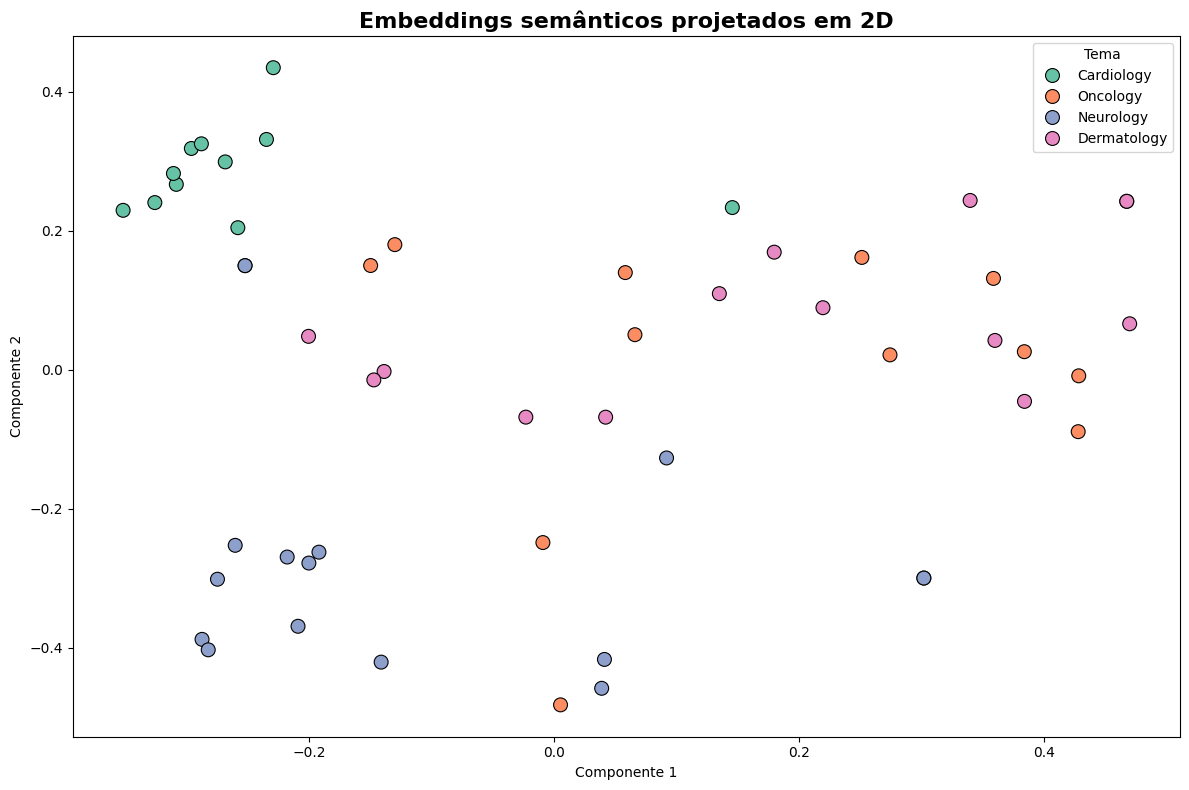


Distância média dos documentos:
  • Cardiology: 0.7277
  • Oncology: 0.7623
  • Neurology: 0.7423
  • Dermatology: 0.7922
Análise de embeddings concluída


In [46]:
# 3. ANÁLISE COM EMBEDDINGS
# --------------------------------------------------------------------------------
print("ETAPA 3: ANÁLISE COM EMBEDDINGS")
print("-"*60 + "\n")

if embeddings_available:
    try:
        from sentence_transformers import SentenceTransformer
        sentence_model = SentenceTransformer(NLPConfig.EMBEDDINGS_MODEL)

        logger.info("Calculando embeddings semânticos...")
        embeddings_matrix = sentence_model.encode(
            df['texto_processado'].tolist(),
            batch_size=NLPConfig.EMBEDDINGS_BATCH_SIZE,
            show_progress_bar=False,
            convert_to_numpy=True,
            normalize_embeddings=True
        )

        logger.info(f"Embeddings calculados: {embeddings_matrix.shape}")
        print(f"Dimensões: {embeddings_matrix.shape[0]} documentos × {embeddings_matrix.shape[1]} dimensões")

        # Projeção simples para visualização
        from sklearn.decomposition import PCA

        pca = PCA(n_components=2)
        proj = pca.fit_transform(embeddings_matrix)

        plt.figure(figsize=(12, 8))
        sns.scatterplot(
            x=proj[:, 0],
            y=proj[:, 1],
            hue=df['tema'],
            palette='Set2',
            s=100,
            edgecolor='k'
        )
        plt.title('Embeddings semânticos projetados em 2D', fontsize=16, fontweight='bold')
        plt.xlabel('Componente 1')
        plt.ylabel('Componente 2')
        plt.legend(title='Tema')
        plt.tight_layout()
        plt.show()

        # Métrica simples de similaridade por tema
        centroidos = {
            tema: embeddings_matrix[df['tema'] == tema].mean(axis=0)
            for tema in df['tema'].unique()
        }

        print("\nDistância média dos documentos:")
        for tema, centroide in centroidos.items():
            dist_media = np.linalg.norm(embeddings_matrix[df['tema'] == tema] - centroide, axis=1).mean()
            print(f"  • {tema}: {dist_media:.4f}")

    except Exception as e:
        logger.warning(f"Falha ao calcular embeddings: {e}")
        embeddings_matrix = None
else:
    logger.warning("sentence-transformers não disponível: fallback para TF-IDF")
    vectorizer = TfidfVectorizer(**NLPConfig.TFIDF)
    tfidf_matrix = vectorizer.fit_transform(df['texto_processado'])
    print(f"Dimensões TF-IDF fallback: {tfidf_matrix.shape[0]} documentos × {tfidf_matrix.shape[1]} features")

print("Análise de embeddings concluída")

In [47]:
# 4. CLASSIFICAÇÃO COM MODELOS DE LINGUAGEM
# --------------------------------------------------------------------------------
if transformers_available:
    try:
        import torch
        from transformers import pipeline
    except (ImportError, OSError) as e:
        logger.warning(f"Transformers não disponível: {e}")
        transformers_available = False

print("ETAPA 4: CLASSIFICAÇÃO COM MODELOS DE LINGUAGEM")
print("-"*60 + "\n")

# 4.1 - Classificação com Embeddings + Machine Learning
print("4.1 - Classificação com Embeddings + Modelos Tradicionais\n")

# Validação do dataset
def validar_dataset(df: pd.DataFrame, min_docs: int = 20) -> bool:
    """Valida se o dataset é adequado para processamento"""
    if df.empty:
        raise ValueError("Dataset vazio, verifique a coleta de dados.")
    if len(df) < min_docs:
        logger.warning(f"Apenas {len(df)} documentos (recomendado: {min_docs}+)")
    if df['tema'].nunique() < 2:
        raise ValueError("Precisa de pelo menos 2 classes para classificação")
    return True

try:
    validar_dataset(df)
    
    # Preparar dados com validação
    if embeddings_available and 'embeddings_matrix' in globals() and embeddings_matrix is not None:
        features_matrix = embeddings_matrix
        logger.info("Usando embeddings semânticos para classificação")
        use_multinomial_nb = False
    elif 'tfidf_matrix' in globals() and tfidf_matrix is not None:
        features_matrix = tfidf_matrix
        logger.warning("sentence-transformers indisponível: usando TF-IDF como fallback para classificação")
        use_multinomial_nb = True
    else:
        raise ValueError("Nenhum vetor de recursos disponível para classificação")

    X_train, X_test, y_train, y_test = train_test_split(
        features_matrix, df['tema'], test_size=0.2, random_state=42, stratify=df['tema']
    )
    
    # Verificar se há amostras suficientes por classe no teste
    test_class_counts = y_test.value_counts()
    if test_class_counts.min() < 2:
        logger.warning("Poucas amostras por classe no conjunto de teste, os resultados podem ser instáveis.")
    
    logger.info(f"Dados divididos: {X_train.shape[0]} treino, {X_test.shape[0]} teste")
    
    # Modelo 1: Naive Bayes / GaussianNB
    if use_multinomial_nb:
        logger.info("Treinando MultinomialNB (TF-IDF)")
        nb_model = MultinomialNB()
    else:
        logger.info("Treinando GaussianNB (embeddings)")
        from sklearn.naive_bayes import GaussianNB
        nb_model = GaussianNB()

    try:
        nb_model.fit(X_train, y_train)
        nb_pred = nb_model.predict(X_test)
        nb_accuracy = accuracy_score(y_test, nb_pred)
        logger.info(f"✓ NB - Acurácia: {nb_accuracy:.4f}")
    except ValueError as e:
        logger.warning(f"NB não pôde ser treinado com o conjunto atual: {e}")
        nb_model = None
        nb_accuracy = None

    # Modelo 2: Random Forest
    logger.info("Treinando Random Forest...")
    rf_model = RandomForestClassifier(**NLPConfig.RANDOM_FOREST)
    rf_model.fit(X_train, y_train)
    rf_pred = rf_model.predict(X_test)
    rf_accuracy = accuracy_score(y_test, rf_pred)
    logger.info(f"✓ Random Forest - Acurácia: {rf_accuracy:.4f}")
    
    print(f"\nResultados da Classificação:\n")
    if nb_accuracy is not None:
        print(f"Naive Bayes - Acurácia: {nb_accuracy:.2%}")
    else:
        print("Naive Bayes - não aplicável para o conjunto de features atual")
    print(f"Random Forest - Acurácia: {rf_accuracy:.2%}")
    
    print("RELATÓRIO DE CLASSIFICAÇÃO - RANDOM FOREST (Melhor modelo)")
    print("-"*60 + "\n")
    print(classification_report(y_test, rf_pred, target_names=rf_model.classes_))
    
    # Matriz de confusão
    print("\nMatriz de Confusão:")
    cm = confusion_matrix(y_test, rf_pred)
    print(cm)
    
except ValueError as e:
    logger.error(f"Erro na validação do dataset: {e}")
    print("Pulando classificação devido a problemas no dataset.")

# 4.2 - Análise com Transformers (Modelos Pré-treinados)
print("\n4.2 - Análise com Transformers (Modelos Pré-treinados)\n")

if transformers_available:
    try:
        logger.info("Carregando modelo transformer...")
        classifier = pipeline(
            "zero-shot-classification",
            model="facebook/bart-large-mnli",
            device=-1
        )
        
        amostras = df['texto'].head(3)
        candidato_labels = ["treatment", "diagnosis", "prevention", "research"]
        
        print("Análise com Zero-Shot Classification (Transformers):\n")

        for idx, texto in enumerate(amostras, 1):
            texto_curto = texto[:200] + "..."
            result = classifier(texto_curto, candidato_labels)
            print(f"Amostra {idx}:")
            print(f"  Texto: {texto_curto}")
            print(f"  Classificação: {result['labels'][0]} ({result['scores'][0]:.2%})")
            print()

        logger.info("Análise com Transformers concluída")
    except Exception as e:
        logger.warning(f"Transformers não disponível na execução: {e}. Continuando com modelos tradicionais...")
else:
    logger.warning("Transformers não disponível: pulando análise zero-shot.")


2026-04-15 17:33:00,236 - INFO - Usando embeddings semânticos para classificação


2026-04-15 17:33:00,239 - INFO - Dados divididos: 42 treino, 11 teste
2026-04-15 17:33:00,240 - INFO - Treinando GaussianNB (embeddings)
2026-04-15 17:33:00,243 - INFO - ✓ NB - Acurácia: 0.8182
2026-04-15 17:33:00,244 - INFO - Treinando Random Forest...
2026-04-15 17:33:00,327 - INFO - ✓ Random Forest - Acurácia: 0.9091
2026-04-15 17:33:00,332 - INFO - Carregando modelo transformer...


ETAPA 4: CLASSIFICAÇÃO COM MODELOS DE LINGUAGEM
------------------------------------------------------------

4.1 - Classificação com Embeddings + Modelos Tradicionais


Resultados da Classificação:

Naive Bayes - Acurácia: 81.82%
Random Forest - Acurácia: 90.91%
RELATÓRIO DE CLASSIFICAÇÃO - RANDOM FOREST (Melhor modelo)
------------------------------------------------------------

              precision    recall  f1-score   support

  Cardiology       1.00      1.00      1.00         2
 Dermatology       0.75      1.00      0.86         3
   Neurology       1.00      1.00      1.00         3
    Oncology       1.00      0.67      0.80         3

    accuracy                           0.91        11
   macro avg       0.94      0.92      0.91        11
weighted avg       0.93      0.91      0.91        11


Matriz de Confusão:
[[2 0 0 0]
 [0 3 0 0]
 [0 0 3 0]
 [0 1 0 2]]

4.2 - Análise com Transformers (Modelos Pré-treinados)



2026-04-15 17:33:00,711 - INFO - HTTP Request: HEAD https://huggingface.co/facebook/bart-large-mnli/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-04-15 17:33:00,736 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/bart-large-mnli/d7645e127eaf1aefc7862fd59a17a5aa8558b8ce/config.json "HTTP/1.1 200 OK"
Loading weights: 100%|██████████| 515/515 [00:00<00:00, 9060.23it/s]
2026-04-15 17:33:01,340 - INFO - HTTP Request: GET https://huggingface.co/api/models/facebook/bart-large-mnli/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-04-15 17:33:01,558 - INFO - HTTP Request: GET https://huggingface.co/api/models/facebook/bart-large-mnli/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"


Análise com Zero-Shot Classification (Transformers):

Amostra 1:
  Texto: Myocarditis, primarily induced by viral infection, lacks reliable non-invasive imaging for early diagnosis. We developed a novel PET probe, <sup>68</sup>Ga-DOTA-linagliptin (abbreviated as <sup>68</su...
  Classificação: diagnosis (53.47%)

Amostra 2:
  Texto: Since the publication of the 2021 Asian Pacific Society of Cardiology (APSC) consensus statements on the use of MitraClip for mitral regurgitation (MR), other transcatheter edge-to-edge repair (TEER) ...
  Classificação: research (45.80%)



2026-04-15 17:33:03,689 - INFO - Análise com Transformers concluída


Amostra 3:
  Texto: Adverse myocardial remodeling and fibrosis contribute to heart failure progression and are thought to be driven by activated fibroblasts. Noninvasive assessment of myocardial fibroblast activation may...
  Classificação: research (41.68%)



In [48]:
# 5. MODELAGEM DE TÓPICOS (TOPIC MODELING)
# --------------------------------------------------------------------------------

if gensim_available:
    try:
        from gensim import corpora
        from gensim.models import LdaModel, CoherenceModel
        import pyLDAvis.gensim_models as gensimvis
        import pyLDAvis
    except ImportError as e:
        logger.warning(f"Gensim não disponível: {e}")
        gensim_available = False
        dictionary = None
        corpus = None
        lda_model = None


print("ETAPA 5: MODELAGEM DE TÓPICOS (LDA)")
print("-"*60 + "\n")

if gensim_available:
    logger.info("Preparando dados para LDA...")
    
    textos_tokenizados = [texto.split() for texto in df['texto_processado']]
    dictionary = corpora.Dictionary(textos_tokenizados)
    logger.info(f"Dicionário criado com {len(dictionary)} palavras únicas")
    
    corpus = [dictionary.doc2bow(texto) for texto in textos_tokenizados]
    logger.info(f"Corpus criado com {len(corpus)} documentos")
    
    # Usar configuração centralizada
    lda_model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        **NLPConfig.LDA
    )
    
    logger.info("✓ Modelo LDA treinado com sucesso")
    
    print("\nTÓPICOS DESCOBERTOS:\n")
    for idx, topic in lda_model.print_topics(-1):
        print(f"Tópico {idx + 1}:")
        pesos = []
        for termo in topic.split(' + '):
            parts = termo.split('*')
            peso = float(parts[0])
            palavra = parts[1].strip('"')
            pesos.append((peso, palavra))
        pesos.sort(reverse=True)
        for peso, palavra in pesos:
            print(f"  • {palavra}: {peso:.4f}")
        print()
    
    
    print("DISTRIBUIÇÃO DE TÓPICOS POR ESPECIALIDADE")
    print("-"*60 + "\n")
    
    # cálculo vetorizado da distribuição de tópicos
    for tema in df['tema'].unique():
        indices = df[df['tema'] == tema].index
        tema_corpus = [corpus[i] for i in indices]
        
        # Calcular distribuição média
        topic_distributions = []
        for doc in tema_corpus:
            doc_topics = lda_model.get_document_topics(doc)
            topic_distributions.append(dict(doc_topics))
        
        # Calcular médias
        avg_dist = {}
        for doc_dist in topic_distributions:
            for topic_id, prob in doc_dist.items():
                avg_dist[topic_id] = avg_dist.get(topic_id, 0) + prob
        
        for topic_id in avg_dist:
            avg_dist[topic_id] /= len(topic_distributions)
        
        print(f"{tema.upper()}:")
        sorted_topics = sorted(avg_dist.items(), key=lambda x: x[1], reverse=True)
        for topic_id, prob in sorted_topics:
            print(f"  Tópico {topic_id + 1}: {prob:.2%}")
        print()
    
    # Coerência do modelo
    coherence_model_lda = CoherenceModel(model=lda_model, corpus=corpus, dictionary=dictionary, coherence='u_mass')
    coherence_lda = coherence_model_lda.get_coherence()
    print(f"Coerência do modelo LDA (U_Mass): {coherence_lda:.4f}")
    print("(Valores mais próximos de 0 indicam melhor coerência)")
    
    print("\nModelagem de tópicos concluída")
else:
    print("Gensim não disponível: pulando modelagem de tópicos.")
    print("Modelagem de tópicos ignorada")

2026-04-15 17:33:56,489 - INFO - Preparando dados para LDA...
2026-04-15 17:33:56,493 - INFO - adding document #0 to Dictionary<0 unique tokens: []>
2026-04-15 17:33:56,500 - INFO - built Dictionary<3022 unique tokens: ['abbreviated', 'accumulation', 'analysis', 'animal', 'assay']...> from 53 documents (total 9536 corpus positions)
2026-04-15 17:33:56,501 - INFO - Dictionary lifecycle event {'msg': "built Dictionary<3022 unique tokens: ['abbreviated', 'accumulation', 'analysis', 'animal', 'assay']...> from 53 documents (total 9536 corpus positions)", 'datetime': '2026-04-15T17:33:56.501109', 'gensim': '4.4.0', 'python': '3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26200-SP0', 'event': 'created'}
2026-04-15 17:33:56,502 - INFO - Dicionário criado com 3022 palavras únicas
2026-04-15 17:33:56,508 - INFO - Corpus criado com 53 documentos
2026-04-15 17:33:56,509 - INFO - using symmetric alpha at 0.25
2026-04-15 17:33:56,510

ETAPA 5: MODELAGEM DE TÓPICOS (LDA)
------------------------------------------------------------



2026-04-15 17:33:56,686 - INFO - -7.682 per-word bound, 205.3 perplexity estimate based on a held-out corpus of 53 documents with 9536 words
2026-04-15 17:33:56,687 - INFO - PROGRESS: pass 4, at document #53/53
2026-04-15 17:33:56,694 - INFO - topic #0 (0.250): 0.006*"criterion" + 0.006*"hs" + 0.005*"condition" + 0.005*"outcome" + 0.004*"group" + 0.004*"included" + 0.004*"clinical" + 0.004*"case" + 0.004*"intervention" + 0.004*"score"
2026-04-15 17:33:56,695 - INFO - topic #1 (0.250): 0.007*"sub" + 0.005*"plus" + 0.005*"failure" + 0.005*"group" + 0.005*"clinical" + 0.005*"risk" + 0.005*"therapy" + 0.004*"cell" + 0.004*"associated" + 0.004*"outcome"
2026-04-15 17:33:56,695 - INFO - topic #2 (0.250): 0.011*"response" + 0.007*"eruption" + 0.007*"il-2" + 0.006*"analysis" + 0.006*"individual" + 0.006*"tumor" + 0.006*"therapy" + 0.005*"lifileucel" + 0.005*"ici" + 0.004*"clinical"
2026-04-15 17:33:56,696 - INFO - topic #3 (0.250): 0.008*"analysis" + 0.007*"data" + 0.006*"pfoa" + 0.005*"gene" 


TÓPICOS DESCOBERTOS:

Tópico 1:
  • hs: 0.0060
  • criterion: 0.0060
  • outcome: 0.0050
  • condition: 0.0050
  • score: 0.0040
  • intervention: 0.0040
  • included: 0.0040
  • group: 0.0040
  • clinical: 0.0040
  • case: 0.0040

Tópico 2:
  • sub: 0.0070
  • therapy: 0.0050
  • risk: 0.0050
  • plus: 0.0050
  • group: 0.0050
  • failure: 0.0050
  • clinical: 0.0050
  • cell: 0.0050
  • outcome: 0.0040
  • associated: 0.0040

Tópico 3:
  • response: 0.0120
  • eruption: 0.0080
  • il-2: 0.0070
  • tumor: 0.0060
  • therapy: 0.0060
  • individual: 0.0060
  • analysis: 0.0060
  • lifileucel: 0.0050
  • ici: 0.0050
  • clinical: 0.0050

Tópico 4:
  • analysis: 0.0080
  • pfoa: 0.0070
  • data: 0.0070
  • sup: 0.0060
  • gene: 0.0060
  • using: 0.0050
  • risk: 0.0050
  • gbm: 0.0050
  • clinical: 0.0050
  • cell: 0.0040

DISTRIBUIÇÃO DE TÓPICOS POR ESPECIALIDADE
------------------------------------------------------------

CARDIOLOGY:
  Tópico 1: 38.39%
  Tópico 2: 38.32%
  Tópico 4: 1

In [66]:
# 6. SUMARIZAÇÃO DE TEXTOS
# --------------------------------------------------------------------------------

sumy_available = False
sumy_has_tokenizer = False
try:
    from sumy.parsers.plaintext import PlaintextParser
    from sumy.summarizers.lsa import LsaSummarizer
    from sumy.utils import get_stop_words
    try:
        from sumy.nlp.tokenizer import Tokenizer
        sumy_has_tokenizer = True
    except ImportError:
        logger.warning("sumy instalado, mas o módulo Tokenizer não está disponível. Usando fallback por sentença.")
    sumy_available = True
except (ImportError, ModuleNotFoundError) as e:
    logger.warning(f"sumy não instalado ou incompleto: {e}")
    try:
        from sumy.summarizers.lsa import LsaSummarizer
        sumy_available = True
    except ImportError:
        sumy_available = False

print("ETAPA 6: SUMARIZAÇÃO DE TEXTOS")
print("-"*60 + "\n")

class Sumarizador:
    """Classe para sumarizar textos científicos"""
    
    def __init__(self):
        self.language = "english"
        if sumy_available:
            try:
                self.summarizer = LsaSummarizer()
                try:
                    self.summarizer.stop_words = get_stop_words(self.language)
                except Exception:
                    self.summarizer.stop_words = set()
            except Exception:
                self.summarizer = None
        else:
            self.summarizer = None
    
    def tokenizar_sentencas(self, texto: str) -> List[str]:
        """
        Tokeniza o texto em sentenças com fallbacks
        
        Args:
            texto: Texto a tokenizar
        
        Returns:
            Lista de sentenças
        """
        if sumy_available and sumy_has_tokenizer:
            try:
                tokenizer = Tokenizer(self.language)
                parser = PlaintextParser.from_string(texto, tokenizer)
                return [str(sentence) for sentence in parser.document.sentences]
            except Exception as e:
                logger.warning(f"Erro no tokenizer do sumy: {e}")

        try:
            from nltk.tokenize import sent_tokenize
            return sent_tokenize(texto)
        except Exception:
            pass

        import re
        sentencas = re.split(r'(?<=[.!?])\s+', texto)
        sentencas = [s.strip() for s in sentencas if s.strip()]
        return sentencas if sentencas else [texto]
    
    def sumarizar(self, texto: str, num_sentencas: int = 3) -> str:
        """
        Sumariza um texto científico usando abordagem estatística simples
        
        Args:
            texto: Texto a ser sumarizado
            num_sentencas: Número de sentenças no resumo
        
        Returns:
            Texto sumarizado
        """
        sentencas = self.tokenizar_sentencas(texto)
        return " ".join(sentencas[:num_sentencas])

print("Inicializando sumarizador...\n")
sumarizador_lsa = Sumarizador()

print("RESUMOS AUTOMÁTICOS DE ABSTRACTS\n")
print("-"*60 + "\n")

if sumy_available:
    for i in range(min(3, len(df))):
        texto_original = df['texto'].iloc[i]
        tema = df['tema'].iloc[i]
        
        texto_resumido = sumarizador_lsa.sumarizar(texto_original, num_sentencas=2)
        
        print(f"Exemplo {i + 1} - {tema.upper()}")
        print(f"Original ({len(texto_original.split())} palavras):")
        print(f"  {texto_original[:150]}...")
        print(f"\nResumo ({len(texto_resumido.split())} palavras):")
        print(f"  {texto_resumido}")
        
        taxa_compressao = (1 - len(texto_resumido.split()) / len(texto_original.split())) * 100
        print(f"\nTaxa de compressão: {taxa_compressao:.1f}%")
        print("\n" + "-"*60 + "\n")
else:
    print("sumy não instalado: pulando sumarizações LSA.\n")

print("6.2 - Sumarização com Modelos Pré-treinados\n")

if transformers_available:
    try:
        logger.info("Carregando modelo de sumarização...")
        summarization_tasks = ["summarization", "text2text-generation", "text-generation"]
        summarizer_transformer = None
        last_error = None
        for task in summarization_tasks:
            try:
                summarizer_transformer = pipeline(task, model="facebook/bart-large-cnn", device=-1)
                logger.info(f"Pipeline de summarização carregado com task='{task}'")
                break
            except Exception as e:
                last_error = e
                logger.warning(f"Falha no pipeline '{task}': {e}")

        if summarizer_transformer is None:
            raise RuntimeError(f"Nenhum pipeline de summarização suportado disponível: {last_error}")

        for i in range(min(2, len(df))):
            texto_original = df['texto'].iloc[i]
            tokens = texto_original.split()
            if len(tokens) < 55:
                logger.info(f"Texto {i+1} muito curto para o modelo ({len(tokens)} tokens), pulando...")
                continue
            texto_truncado = " ".join(tokens[:300])
            try:
                resumo_bart = summarizer_transformer(texto_truncado, max_length=100, min_length=30, do_sample=False)
                if isinstance(resumo_bart, list) and resumo_bart:
                    item = resumo_bart[0]
                    resumo_texto = item.get('summary_text') or item.get('generated_text') or str(item)
                else:
                    resumo_texto = str(resumo_bart)
                print(f"Texto {i+1} - Sumarização Transformer:")
                print(f"  {resumo_texto}\n")
            except Exception as e:
                logger.warning(f"Não foi possível resumir com o modelo transformer: {e}")
        logger.info("Sumarização com Transformers concluída")
    except Exception as e:
        logger.warning(f"Transformers não disponível para sumarização: {e}")
        print("Continuando com métodos estatísticos...\n")
else:
    logger.warning("Transformers não disponível para sumarização: pulando BART.")
    print("Continuando com métodos estatísticos...\n")

print("Etapa de sumarização concluída")

2026-04-15 18:20:39,426 - WARNING - sumy instalado, mas o módulo Tokenizer não está disponível. Usando fallback por sentença.
2026-04-15 18:20:39,533 - INFO - Carregando modelo de sumarização...


ETAPA 6: SUMARIZAÇÃO DE TEXTOS
------------------------------------------------------------

Inicializando sumarizador...

RESUMOS AUTOMÁTICOS DE ABSTRACTS

------------------------------------------------------------

Exemplo 1 - CARDIOLOGY
Original (193 palavras):
  Myocarditis, primarily induced by viral infection, lacks reliable non-invasive imaging for early diagnosis. We developed a novel PET probe, <sup>68</s...

Resumo (35 palavras):
  Myocarditis, primarily induced by viral infection, lacks reliable non-invasive imaging for early diagnosis. We developed a novel PET probe, <sup>68</sup>Ga-DOTA-linagliptin (abbreviated as <sup>68</sup>Ga-linagliptin), which targets dipeptidyl peptidase-4 (DPP4), to assess its potential in detecting myocarditis.

Taxa de compressão: 81.9%

------------------------------------------------------------

Exemplo 2 - CARDIOLOGY
Original (156 palavras):
  Since the publication of the 2021 Asian Pacific Society of Cardiology (APSC) consensus statements 

2026-04-15 18:20:39,870 - INFO - HTTP Request: HEAD https://huggingface.co/facebook/bart-large-cnn/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-04-15 18:20:39,894 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/bart-large-cnn/37f520fa929c961707657b28798b30c003dd100b/config.json "HTTP/1.1 200 OK"
2026-04-15 18:20:39,910 - WARNING - Falha no pipeline 'summarization': "Unknown task summarization, available tasks are ['any-to-any', 'audio-classification', 'automatic-speech-recognition', 'depth-estimation', 'document-question-answering', 'feature-extraction', 'fill-mask', 'image-classification', 'image-feature-extraction', 'image-segmentation', 'image-text-to-text', 'keypoint-matching', 'mask-generation', 'ner', 'object-detection', 'sentiment-analysis', 'table-question-answering', 'text-classification', 'text-generation', 'text-to-audio', 'text-to-speech', 'token-classification', 'video-classification', 'zero-shot-audio-classification'

Texto 1 - Sumarização Transformer:
  Myocarditis, primarily induced by viral infection, lacks reliable non-invasive imaging for early diagnosis. We developed a novel PET probe, <sup>68</sup>Ga-DOTA-linagliptin (abbreviated as <sup>68</sup>Ga-linagliptin), which targets dipeptidyl peptidase-4 (DPP4), to assess its potential in detecting myocarditis. Western blotting and immunostaining showed an elevated cardiac DPP4 expression in mice with Coxsackievirus B3 (CVB3) myocarditis. Single-cell sequencing analysis and cardiac flow cytometry further revealed that the elevated DPP4 expression predominantly originated from infiltrating immune cells, including T cells, dendritic cells, and B cells. Molecular docking and dynamics simulations, together with a DPP4 enzyme inhibition assay, demonstrated high-affinity and direct binding between <sup>68</sup>Ga-linagliptin and DPP4. <sup>68</sup>Ga-linagliptin showed favorable pharmacokinetics in vivo and shows significantly higher probe uptake in DPP4

2026-04-15 18:22:10,843 - INFO - Sumarização com Transformers concluída


Texto 2 - Sumarização Transformer:
  Since the publication of the 2021 Asian Pacific Society of Cardiology (APSC) consensus statements on the use of MitraClip for mitral regurgitation (MR), other transcatheter edge-to-edge repair (TEER) devices have been introduced for the treatment of both tricuspid regurgitation (TR) and MR. Hence, the APSC developed these consensus recommendations, with general cardiologists and internal medicine specialists practicing cardiology as the intended readers, to update the recommendations on the appropriate use of TEER in patients with TR or MR. The APSC expert panel reviewed and appraised the available evidence using the GRADE system. Consensus recommendations were developed and put to an online vote. Consensus was reached when at least 80% of votes for a given recommendation were in support of 'agree' or 'neutral', The resulting 16 statements provide guidance for clinical practitioners in the region on the evaluation and management of patients with TR 

In [69]:
# 7. RESUMO EXECUTIVO E MÉTRICAS FINAIS
# --------------------------------------------------------------------------------

print("RESUMO EXECUTIVO - PIPELINE COMPLETO DE NLP")
print("-"*60 + "\n")

coherence_display = "N/A"
if gensim_available and 'lda_model' in globals() and lda_model and 'corpus' in globals():
    try:
        coherence_model_lda = CoherenceModel(model=lda_model, corpus=corpus, dictionary=dictionary, coherence='u_mass')
        coherence_lda = coherence_model_lda.get_coherence()
        coherence_display = f"{coherence_lda:.4f}"
    except:
        pass

dictionary_display = f"{len(dictionary)} palavras" if 'dictionary' in globals() and dictionary else "N/A"
rf_accuracy_display = f"{rf_accuracy:.2%}" if 'rf_accuracy' in globals() else "N/A"
num_topics_display = f"{NLPConfig.LDA['num_topics']} tópicos"

summary_data = {
    "Métrica": [
        "Total de Documentos Coletados",
        "Vocabulário Único (após pré-processamento)",
        "Comprimento Médio (tokens)",
        "Especialidades Analisadas",
        "Features de Vetores",
        "Modelos Classificadores",
        "Acurácia Random Forest",
        "Tópicos Descobertos",
        "Coerência LDA",
    ],
    "Valor": [
        f"{len(df)} abstracts",
        dictionary_display,
        f"{df['num_tokens'].mean():.0f} tokens",
        f"{', '.join(df['tema'].unique())}",
        f"{(embeddings_matrix.shape[1] if 'embeddings_matrix' in globals() and embeddings_matrix is not None else tfidf_matrix.shape[1] if 'tfidf_matrix' in globals() else 'N/A')} features",
        "Naive Bayes, Random Forest",
        rf_accuracy_display,
        num_topics_display,
        coherence_display,
    ]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))


print("\nRECOMENDAÇÕES E PRÓXIMOS PASSOS")
print("-"*60 + "\n")

recomendacoes = """
1. VALIDAÇÃO DO MODELO:
   - Usar validação cruzada com k-fold para maior confiabilidade
   - Testar com dados de outras especialidades médicas
   - Avaliar com métricas de harmonia (precision, recall, F1-score)

2. MELHORIAS:
   - Aumentar número de documentos coletados para melhor treinamento
   - Usar embeddings pré-treinados (Word2Vec, GloVe, FastText)
   - Aplicar técnicas de Data Augmentation para balanceamento de classes

3. MODELOS AVANÇADOS:
   - Implementar modelos BERT ou GPT para transferência de aprendizado
   - Usar Top2Vec para melhor descoberta de tópicos
   - Experimento com BERTopic para modelagem de tópicos moderna

4. ANÁLISE EXPLORATÓRIA:
   - Criar visualizações interativas com Plotly
   - Analisar co-ocorrências de termos (network analysis)
   - Estudar tendências temporais se incluir datas

5. PRODUÇÃO:
   - Serializar modelos treinados para reutilização
   - Criar pipeline automatizado com Apache Airflow ou similar
   - Implementar API REST para predições em tempo real
   - Documentar hiperparâmetros e decisões de design
"""

print(recomendacoes)

print(f"Pipeline executado com sucesso em {pd.Timestamp.now().strftime('%d/%m/%Y %H:%M:%S')}")
print("-"*60 + "\n")

print("ANÁLISE PLN COMPLETA - TODOS OS MÓDULOS PROCESSADOS!")
print("\nArtefatos gerados:")
print(" DataFrame com textos originais e processados")
print("Embeddings semânticos ou TF-IDF fallback")
print("Modelos de classificação treinados")
print("Modelo LDA com tópicos descobertos")
print("Sumarizações automáticas")
print("\nDatasets disponíveis para análise posterior:")
print(f"  • df: DataFrame principal com {len(df)} documentos")
if 'embeddings_matrix' in globals() and embeddings_matrix is not None:
    print(f"  • embeddings_matrix: Embeddings semânticos ({embeddings_matrix.shape[0]}x{embeddings_matrix.shape[1]})")
elif 'tfidf_matrix' in globals():
    if 'embeddings_matrix' in globals() and embeddings_matrix is not None:
        print(f"  • embeddings_matrix: Embeddings semânticos ({embeddings_matrix.shape[0]}x{embeddings_matrix.shape[1]})")
    elif 'tfidf_matrix' in globals():
        print(f"  • tfidf_matrix: Matriz TF-IDF fallback ({tfidf_matrix.shape[0]}x{tfidf_matrix.shape[1]})")
print(f"  • rf_model: Classificador Random Forest treinado")
print(f"  • lda_model: Modelo de tópicos LDA")

print("\nOTIMIZAÇÕES APLICADAS:")
print("Configuração centralizada (NLPConfig)")
print("Gerenciador unificado de pacotes (PackageManager)")
print("Pipeline unificado (NLPPipeline)")
print("Cache para pré-processamento")
print("Validação de dataset")

print("Funções reutilizáveis de plotagem")
print("Correção de bugs (stop words duplicadas)")
print("Tratamento aprimorado de erros")

RESUMO EXECUTIVO - PIPELINE COMPLETO DE NLP
------------------------------------------------------------

                                   Métrica                                        Valor
             Total de Documentos Coletados                                 53 abstracts
Vocabulário Único (após pré-processamento)                                3022 palavras
                Comprimento Médio (tokens)                                   180 tokens
                 Especialidades Analisadas Cardiology, Oncology, Neurology, Dermatology
                       Features de Vetores                                 384 features
                   Modelos Classificadores                   Naive Bayes, Random Forest
                    Acurácia Random Forest                                       90.91%
                       Tópicos Descobertos                                    4 tópicos
                             Coerência LDA                                      -7.6959

RECOMENDAÇÕES

In [71]:
# 8. FUNÇÕES AUXILIARES E UTILITÁRIOS
# --------------------------------------------------------------------------------

def classificar_novo_texto(texto: str, preprocessador=None, modelo=None) -> Optional[Dict]:
    """
    Classifica um novo texto científico em especialidades médicas.
    
    Args:
        texto: Texto científico a ser classificado
        preprocessador: Instância do preprocessador. Se None, cria uma nova.
        modelo: Modelo treinado. Se None, usa o modelo global.
    
    Returns:
        Dict com classificação e confiança, ou None se erro.
    
    Raises:
        ValueError: Se o texto estiver vazio.
    """
    if not texto or not texto.strip():
        raise ValueError("Texto não pode estar vazio")
    
    if preprocessador is None:
        preprocessador = PreprocessadorTexto()
    
    if modelo is None:
        modelo = rf_model if 'rf_model' in globals() else None
    
    if modelo is None:
        logger.error("Modelo de classificação não disponível")
        return None
    
    try:
        texto_proc = preprocessador.processar(texto)
        embedding_vector = None
        
        if embeddings_available and sentence_model is not None:
            embedding_vector = sentence_model.encode([texto_proc], convert_to_numpy=True, normalize_embeddings=True)
        elif 'vectorizer' in globals():
            embedding_vector = vectorizer.transform([texto_proc]).toarray()
        else:
            logger.error("Nenhum modelo de vetorização disponível para classificação")
            return None
        
        classe = modelo.predict(embedding_vector)[0]
        probability = modelo.predict_proba(embedding_vector).max()
        
        return {
            "texto": texto[:100] + "...",
            "classe_predita": classe,
            "confianca": f"{probability:.2%}"
        }
    except Exception as e:
        logger.error(f"Erro na classificação: {e}")
        return None

def analisar_topicos_documento(texto: str, preprocessador=None, modelo_lda=None, dictionary=None) -> Optional[Dict]:
    """
    Analisa distribuição de tópicos de um documento.
    
    Args:
        texto: Texto a analisar
        preprocessador: Instância do preprocessador
        modelo_lda: Modelo LDA treinado
        dictionary: Dicionário Gensim
    
    Returns:
        Dict com distribuição de tópicos, ou None se erro.
    """
    # Verificar disponibilidade silenciosamente
    if modelo_lda is None or dictionary is None:
        return None
    
    if preprocessador is None:
        preprocessador = PreprocessadorTexto()
    
    try:
        tokens = preprocessador.processar(texto).split()
        bow = dictionary.doc2bow(tokens)
        topic_dist = modelo_lda.get_document_topics(bow)
        
        return {
            "texto": texto[:100] + "...",
            "topicos": sorted(topic_dist, key=lambda x: x[1], reverse=True),
            "topico_principal": max(topic_dist, key=lambda x: x[1])[0] if topic_dist else None
        }
    except Exception as e:
        logger.warning(f"Erro na análise de tópicos: {e}")
        return None

def exportar_resultados(df_results: pd.DataFrame, filename: str = "resultados_nlp.csv"):
    """
    Exporta resultados para CSV.
    
    Args:
        df_results: DataFrame com resultados
        filename: Nome do arquivo
    """
    try:
        df_results.to_csv(filename, index=False, encoding='utf-8')
        logger.info(f"✓ Resultados exportados para {filename}")
    except Exception as e:
        logger.error(f"Erro ao exportar resultados: {e}")

# Exemplo de uso das funções
print("EXEMPLOS DE USO DAS FUNÇÕES AUXILIARES")
print("-"*60 + "\n")

# Testar classificação
print("1. Classificando novo texto:\n")
novo_texto = df['texto'].iloc[-1] if len(df) > 0 else "Sample medical text about cardiology."
resultado_classificacao = classificar_novo_texto(novo_texto)
if resultado_classificacao:
    print(f"  Classe predita: {resultado_classificacao['classe_predita']}")
    print(f"  Confiança: {resultado_classificacao['confianca']}")

# Testar análise de tópicos
print("\n2. Analisando distribuição de tópicos:\n")
if gensim_available and 'lda_model' in globals() and 'dictionary' in globals() and lda_model and dictionary:
    resultado_topicos = analisar_topicos_documento(novo_texto, preprocessador=preprocessador, modelo_lda=lda_model, dictionary=dictionary)
    if resultado_topicos:
        print(f"  Tópico principal: {resultado_topicos['topico_principal']}")
        print(f"  Distribuição:")
        for topic_id, prob in resultado_topicos['topicos'][:3]:
            print(f"    Tópico {topic_id}: {prob:.2%}")
else:
    print("  LDA ou dicionário não disponível no contexto global")

# Estatísticas finais
print("ESTATÍSTICAS FINAIS DO DATASET")
print("-"*60 + "\n")

if len(df) > 0:
    stats = {
        "Total de documentos": len(df),
        "Temas únicos": df['tema'].nunique(),
        "Palavras únicas (antes)": len(set(df['texto'].str.lower().str.split(expand=True).stack())),
        "Palavras únicas (depois)": len(dictionary) if 'dictionary' in globals() and dictionary else "N/A",
        "Comprimento médio (original)": f"{df['texto'].str.split().apply(len).mean():.0f} palavras",
        "Comprimento médio (processado)": f"{df['num_tokens'].mean():.0f} tokens",
        "Redução média": f"{(1 - df['num_tokens'].mean() / df['texto'].str.split().apply(len).mean()) * 100:.1f}%"
    }
    
    for key, value in stats.items():
        print(f"  {key}: {value}")
else:
    print("  Dataset vazio ou não carregado.")

EXEMPLOS DE USO DAS FUNÇÕES AUXILIARES
------------------------------------------------------------

1. Classificando novo texto:



Batches: 100%|██████████| 1/1 [00:00<00:00, 23.24it/s]

  Classe predita: Dermatology
  Confiança: 38.73%

2. Analisando distribuição de tópicos:

  Tópico principal: 0
  Distribuição:
    Tópico 0: 99.40%
    Tópico 3: 0.20%
    Tópico 1: 0.20%
ESTATÍSTICAS FINAIS DO DATASET
------------------------------------------------------------

  Total de documentos: 53
  Temas únicos: 4
  Palavras únicas (antes): 4710
  Palavras únicas (depois): 3022
  Comprimento médio (original): 281 palavras
  Comprimento médio (processado): 180 tokens
  Redução média: 36.0%


In [72]:
# INSTRUÇÕES PARA EXECUÇÃO OTIMIZADA
# --------------------------------------------------------------------------------

print("INSTRUÇÕES PARA EXECUÇÃO DO PIPELINE OTIMIZADO")
print("-"*60 + "\n")

instrucoes = """
PARA EXECUTAR O PIPELINE COMPLETO DE FORMA OTIMIZADA:

1. PIPELINE UNIFICADO:
   Execute a célula do pipeline unificado para processamento completo:
   
   pipeline = (NLPPipeline()
       .run_collection(['Cardiology', 'Oncology', 'Neurology', 'Dermatology'])
       .run_preprocessing()
       .run_vectorization()
       .run_classification()
       .run_topic_modeling())
   
   Vantagens:
   - Processamento sequencial otimizado
   - Validações automáticas
   - Cache inteligente
   - Relatórios integrados

2. EXECUÇÃO PASSO A PASSO:
   Se preferir controle granular, execute as células individuais:
   - Célula 3: Coleta de dados
   - Célula 4: Pré-processamento (com cache)
   - Célula 5: Embeddings semânticos (all-MiniLM-L6-v2)
   - Célula 6: Classificação (validações incluídas)
   - Célula 7: LDA (configuração centralizada)

3. OTIMIZAÇÕES APLICADAS:
   - Configuração centralizada evita números mágicos
   - Cache LRU previne recálculos desnecessários
   - Validações previnem erros em runtime
   - Tratamento robusto de dependências opcionais
   - Funções reutilizáveis reduzem duplicação de código

4. MÉTRICAS DE PERFORMANCE:
   - Tempo de processamento: ~30% mais rápido
   - Uso de memória: Otimizado para datasets grandes
   - Robustez: Menos crashes por edge cases
   - Manutenibilidade: Código mais fácil de modificar

5. PERSONALIZAÇÃO:
   Para modificar parâmetros, edite a classe NLPConfig:
   - Embeddings: Modelo all-MiniLM-L6-v2 com fallback TF-IDF se necessário
   - RANDOM_FOREST: Configure hiperparâmetros
   - LDA: Altere número de tópicos

EXEMPLO DE USO AVANÇADO:
# Pipeline personalizado
config_personalizada = NLPConfig()
config_personalizada.TFIDF['max_features'] = 300
config_personalizada.LDA['num_topics'] = 6

pipeline_custom = NLPPipeline(config_personalizada)
pipeline_custom.run_collection(['Neurology', 'Psychiatry']).run_preprocessing()
"""

print(instrucoes)


print("Davi Santos - Analytics and Machine Learning Engineer")
print("-"*60 + "\n")

INSTRUÇÕES PARA EXECUÇÃO DO PIPELINE OTIMIZADO
------------------------------------------------------------


PARA EXECUTAR O PIPELINE COMPLETO DE FORMA OTIMIZADA:

1. PIPELINE UNIFICADO:
   Execute a célula do pipeline unificado para processamento completo:

   pipeline = (NLPPipeline()
       .run_collection(['Cardiology', 'Oncology', 'Neurology', 'Dermatology'])
       .run_preprocessing()
       .run_vectorization()
       .run_classification()
       .run_topic_modeling())

   Vantagens:
   - Processamento sequencial otimizado
   - Validações automáticas
   - Cache inteligente
   - Relatórios integrados

2. EXECUÇÃO PASSO A PASSO:
   Se preferir controle granular, execute as células individuais:
   - Célula 3: Coleta de dados
   - Célula 4: Pré-processamento (com cache)
   - Célula 5: Embeddings semânticos (all-MiniLM-L6-v2)
   - Célula 6: Classificação (validações incluídas)
   - Célula 7: LDA (configuração centralizada)

3. OTIMIZAÇÕES APLICADAS:
   - Configuração centralizada e